<a href="https://colab.research.google.com/github/your-org/alexpose/blob/main/experiments/multiple-sclerosis/03_sjepa_model_and_pretrain_normal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 03 · How S-JEPA learns from walking skeletons

**Our task: learn useful descriptions of movement by predicting information
hidden from part of the model.** Later notebooks will test whether those
descriptions help distinguish the dataset's normal, multiple sclerosis (MS),
and Parkinson's disease (PD) labels.

Imagine watching a stick figure walk while some body parts are covered.
Its visible movement gives clues about the hidden parts. S-JEPA practices a
related task, but its answers are **lists of learned numbers called features**,
rather than drawings of the missing joints. It does not receive condition
labels as answers during this training stage.

This tutorial assumes that you understand coordinates, averages, and graphs.
You do not need calculus or previous experience with neural networks.

**Reading a completed run:** read the explanations and saved outputs from
top to bottom. You do not need to run training again to read them. Step 9
interprets the saved September 20, 2026 run. If you train again, your new
outputs take priority over that dated example.

| Step | What you will understand |
|---|---|
| 1–2 | Set up the experiment and keep training sources separate |
| 3–4 | Turn coordinates into tokens and follow the student–teacher model |
| 5–6 | Hide information, calculate an error, and update the model |
| 7–8 | Know what training should produce and read each diagnostic |
| 9–10 | Interpret this run, identify its limits, and prepare for notebook 04 |

A few words we will use:

| Word | Meaning here |
|---|---|
| **Window** | A short sequence cut from a walking clip |
| **Token** | Four consecutive frames of one body landmark, converted into a list of numbers |
| **Encoder** | A neural network that converts input tokens into learned features |
| **Embedding** | A compact list of features describing a window or clip |
| **Parameter / weight** | An adjustable number inside the network |
| **Batch** | A group of windows processed for one training update |
| **Loss** | A numerical penalty for the model's predictions |
| **Checkpoint** | A saved model and information about how it was trained |

The filename contains `pretrain_normal` for historical reasons. The current
experiment trains on **all three conditions within the training partition**.
This is *self-supervised learning*: the skeleton data supplies the prediction
targets. The condition labels do not enter the loss.

## Step 1 · Set up the experiment

The next three cells make the Python packages available, locate this project,
and select the paths and model profile. Notebook 01 must already have created
the pose cache in `artifacts/keypoints-full/`. Notebook 02 explains the masks
visually and is useful preparation.

- **`laptop`** is the smaller teaching model used in the saved run.
- **`gpu`** uses longer windows and a larger network. The numerical examples
  below describe `laptop`; the code reads the active configuration.
- **`SJEPA_SMOKE=1`** selects a tiny model and only four updates. It checks
  whether the pipeline runs; it cannot establish useful learning.

Expected setup output: the experiment folder, the video folder, and the
selected profile. `mps`, printed later, means Apple's GPU backend; `cuda`
means an NVIDIA GPU backend; `cpu` means the main processor. These names
describe where arithmetic runs, not the quality of the learned features.

In [1]:
# --- Setup: install dependencies (Colab installs; local usually already has them) ---
import importlib, importlib.util, subprocess, sys, os

IN_COLAB = 'google.colab' in sys.modules

def _need(mod):
    return importlib.util.find_spec(mod) is None

# Light deps used by every notebook.
_pkgs = []
for mod, pip_name in [('cv2','opencv-python'), ('mediapipe','mediapipe'),
                      ('sklearn','scikit-learn'), ('pandas','pandas'),
                      ('matplotlib','matplotlib'), ('tqdm','tqdm')]:
    if _need(mod):
        _pkgs.append(pip_name)
# torch is guarded so Colab's preinstalled GPU torch is never downgraded.
if _need('torch'):
    _pkgs.append('torch')
if _pkgs:
    print('installing:', _pkgs)
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *_pkgs])
else:
    print('all light dependencies already present')

all light dependencies already present


In [2]:
# --- Make `sjepa` and `ambient` importable, locally and in Colab ---
from pathlib import Path
import sys, subprocess

def _find_exp_dir():
    # Local run: this notebook sits in experiments/multiple-sclerosis.
    here = Path.cwd()
    for p in [here, *here.parents]:
        if (p / 'sjepa' / '__init__.py').exists():
            return p
    return None

EXP_DIR = _find_exp_dir()
if EXP_DIR is None:
    # Colab: clone the repo, then point at the experiment folder.
    REPO = 'https://github.com/your-org/alexpose.git'  # <-- edit to your fork
    if not Path('alexpose').exists():
        subprocess.check_call(['git', 'clone', '--depth', '1', REPO])
    EXP_DIR = Path('alexpose') / 'experiments' / 'multiple-sclerosis'

REPO_ROOT = EXP_DIR.parents[1]
for p in (str(EXP_DIR), str(REPO_ROOT)):
    if p not in sys.path:
        sys.path.insert(0, p)
print('experiment dir:', EXP_DIR)
print('repo root     :', REPO_ROOT)

experiment dir: /Users/alexmui/dev/alexpose/experiments/multiple-sclerosis
repo root     : /Users/alexmui/dev/alexpose


In [3]:
# --- Paths and profile (reads the root .env if python-dotenv is present) ---
import os
try:
    from dotenv import load_dotenv
    load_dotenv(REPO_ROOT / '.env')
except Exception:
    pass

VIDEO_DIR = EXP_DIR / 'video-data-full'
ARTIFACT_DIR = EXP_DIR / 'artifacts'
KEYPOINTS_DIR = ARTIFACT_DIR / 'keypoints-full'
IMAGES_DIR = EXP_DIR / 'images'
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

# Pick the model size profile. 'laptop' is the fast default; set SJEPA_PROFILE=gpu
# in your .env for a larger model, or SJEPA_SMOKE=1 for a near-instant test run.
os.environ.setdefault('SJEPA_PROFILE', 'laptop')
print('SJEPA_PROFILE =', os.environ['SJEPA_PROFILE'],
      '| SJEPA_SMOKE =', os.environ.get('SJEPA_SMOKE', '0'))
print('video dir     :', VIDEO_DIR)

SJEPA_PROFILE = laptop | SJEPA_SMOKE = 0
video dir     : /Users/alexmui/dev/alexpose/experiments/multiple-sclerosis/video-data-full


## Step 2 · Split source videos before making windows

A **source video** can produce several clips. A clip can produce several
overlapping windows. Those windows are close relatives: some contain many
of the same frames. Putting relatives in training and testing would make
the test too easy, like practicing with part of tomorrow's exam.

We keep every source's clips and windows together. The shared **registry**
is a saved list of these assignments. Its checksum is a fingerprint used to
detect a different registry. The loader also checks the cache and reviewed
exclusions; this keeps notebooks 02–06 on the same dataset and split.

We divide the sources into five outer groups, called **folds**. Notebook 03
demonstrates `FOLD = 0`. Notebook 06 independently trains a fresh model in
each of the five rounds. Each round reserves roughly 60% of sources for
training, 20% for validation, and 20% for testing.

**Read the first three rows of the table below for this notebook's round:**

| Partition, fold 0 | Sources | Clips | Role |
|---|---:|---:|---|
| Training | 24 | 51 | Supplies all windows used to update this model |
| Validation | 8 | 19 | Used in notebook 04 to compare training budgets |
| Test | 9 | 18 | Reserved for notebook 06's final evaluation procedure |
| Total | 41 | 88 | Usable cached clips; three raw clips were excluded |

The training clips comprise **15 normal, 23 MS, and 13 PD clips**, from
**9, 8, and 7 sources**, respectively. Labels help balance the source split,
but are ignored by the self-supervised training loss. Even *unlabeled*
validation or test motion must stay out of training: seeing it would still
allow the model to adapt to it.

A source ID identifies a recording, not a verified individual person.
Keeping source IDs separate cannot rule out the same person appearing in
different recordings. See [the split method](docs/11-full-data-splits.md).

In [4]:
from IPython.display import display
import pandas as pd
from sjepa.splits import load_full_registry, partition_records, split_summary
records, registry = load_full_registry(EXP_DIR)
FOLD = 0  # teaching example; notebook 06 independently trains all five folds
train_recs, val_recs, test_recs = partition_records(records, registry, FOLD)
display(pd.DataFrame(split_summary(records, registry)))
print('usable clips:', len(records), '| excluded raw clips:', len(registry['inventory']['exclusions']))
print('registry:', registry['registry_sha256'])

,fold,partition,clips,sources,normal_clips,normal_sources,ms_clips,ms_sources,pd_clips,pd_sources
0,0,train,51,24,15,9,23,8,13,7
1,0,validation,19,8,3,3,2,2,14,3
2,0,test,18,9,6,4,4,3,8,2
3,1,train,58,24,12,9,22,8,24,7
4,1,validation,17,9,7,4,4,3,6,2
5,1,test,13,8,5,3,3,2,5,3
6,2,train,54,24,15,9,21,8,18,7
7,2,validation,17,9,6,4,5,3,6,2
8,2,test,17,8,3,3,3,2,11,3
9,3,train,53,24,13,9,23,8,17,7


usable clips: 88 | excluded raw clips: 3
registry: 9496e61b050fc8b62ccbc59cb737376396205a3356b323733b9b8915d56600e1


## Step 3 · Turn a short movement into tokens

The model reads saved skeleton coordinates, not video pixels. Each frame
contains 33 body landmarks. Each landmark has three channels:
**horizontal position `x`, vertical position `y`, and visibility** (the
pose detector's confidence that the landmark is visible). Visibility is
not depth, and it is not the training mask.

Notebook 01 already centered each frame at the pelvis and divided its
coordinates by torso length. This reduces differences caused by location
in the image and apparent body size. It does not remove every difference
caused by the camera, viewpoint, or pose detector.

For the saved laptop configuration:

1. Take **32 frames** sampled at **15 frames per second**: about 2.1 seconds
   of motion. Consecutive windows start 16 frames apart, so they overlap.
   A clip shorter than 32 frames is padded by repeating its last frame.
2. Group **four adjacent frames of one landmark** into one token.
   One token starts with `4 × 3 = 12` numbers.
3. A learned linear mapping converts those 12 numbers into **96 features**.
   The model also adds learned information identifying the landmark and
   the time block. This is the token's “address.”
4. There are `32 ÷ 4 = 8` time blocks and 33 landmarks, giving
   **`8 × 33 = 264` tokens per window**.

![A 32-frame skeleton window becomes 264 tokens. Each token groups four frames of one landmark, projects 12 input numbers into 96 features, and receives joint and time information.](images/notebook03_data_to_tokens.svg)

A batch of 32 windows starts with shape **`(32, 32, 33, 3)`**:
`(windows, frames, landmarks, channels)`. After tokenization it has shape
**`(32, 264, 96)`**: `(windows, tokens, features)`. The two initial 32s mean
different things. Neither 96 features nor 264 tokens is a number of classes.

In this saved fold there are **207 available training windows**. They remain
strongly related to their 51 clips and 24 sources; 207 windows do not mean
207 independent people or recordings.

## Step 4 · Meet the student, predictor, and slow teacher

The diagram in the next cell has two paths through the same training window:

1. **View encoder, or student:** uses the visible parts of a randomly
   transformed window to form features. Attention lets a token use
   information from other visible joints and time blocks. Hidden inputs
   cannot act as context; their output slots are replaced with a learned
   placeholder before the predictor receives them.
2. **Predictor:** receives those context features, placeholders, and joint
   and time addresses. It predicts a 96-number feature vector at each slot.
   The address distinguishes, for example, a hidden ankle in time block 2
   from a hidden shoulder in time block 6.
3. **Target encoder, or teacher:** sees the complete, original window.
   Its features at the hidden slots become the targets for the predictor.
   The teacher does not receive updates directly from the loss.

The teacher starts as a copy of the student and then changes slowly as the
student learns. “Teacher” is a useful analogy; it is not a human expert or
a model that already knows diagnoses. Allowing it to see the full **training**
window creates a target, just as the answer key contains information hidden
from a student. It does not give either network access to the test partition.

The printed `encoder 3L × 96d × 4h` means **three processing layers**, each
with **96 feature dimensions** and **four attention heads**. A head is a
separate learned way of combining information from tokens. The predictor
has two layers and width 96. The teacher has the same encoder architecture
as the student.

**One potentially confusing line:** `describe(cfg)` prints the older
`pretrain 40ep, finetune 30ep` configuration fields. This notebook's active
training helper uses **800 optimizer updates**, not those epoch counts.
An epoch usually means one pass through a dataset; this sampler draws
windows with replacement, so an update budget is the useful description.

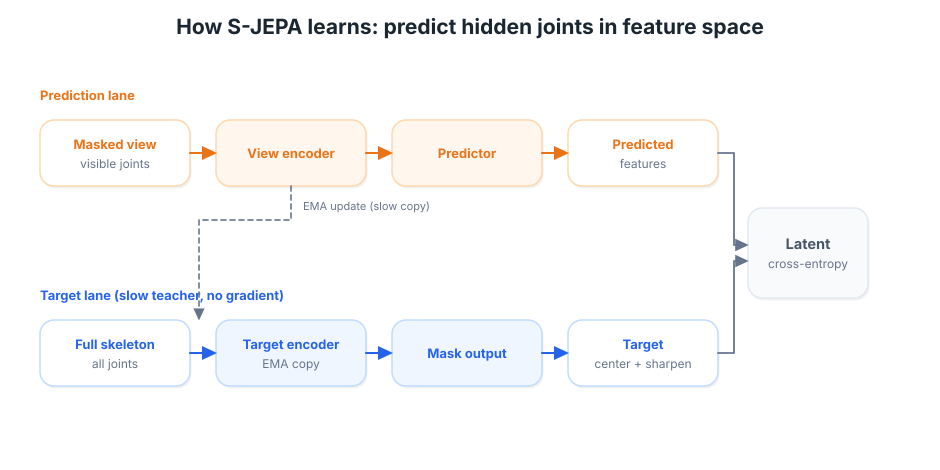

profile=laptop | window=32f @ 15fps | tokens N=264 (8 time x 33 joints) | encoder 3L x 96d x 4h | predictor 2L x 96d | pretrain 40ep, finetune 30ep
device: mps
checkpoint directory: /Users/alexmui/dev/alexpose/experiments/multiple-sclerosis/artifacts/runs/full-v1/9496e61b050f/laptop-1d09c8e1eea5/fold-0


In [5]:
from IPython.display import SVG, display
display(SVG(filename=str(IMAGES_DIR / 'sjepa_two_lane.svg')))
from sjepa.config import get_config, describe
from sjepa.models import build_model, pick_device
from sjepa.splits import fold_run_dir
cfg = get_config(); device = pick_device()
RUN_DIR = fold_run_dir(EXP_DIR, registry, cfg, FOLD)
model = build_model(cfg, device=device, repaired=True)
print(describe(cfg)); print('device:', device)
print('checkpoint directory:', RUN_DIR)

## Step 5 · Make a fresh prediction puzzle for each window

A **target mask** marks the tokens whose features the student must predict.
A **context mask** marks the tokens it can use as clues. The target mask
aims to hide roughly **60%** of the 264 tokens: about 158. The exact count
varies because whole connected regions are added, and those regions can
overlap. It is not an exact 60/40 split in every example.

Masks cover groups such as a leg or the trunk over consecutive time blocks.
Each window in a batch gets its own random mask, and new masks are sampled
on later updates. Shoulder and leg regions receive a sampling preference;
the setting `clinical_bias=1.5` is a region-selection weight, not a guarantee
that each joint is hidden exactly 1.5 times as often.

Every joint can serve as context or a target across repeated mask draws.
One particular draw can still hide a joint for the entire window. The code
guarantees some context and at least one visible shoulder-or-leg token
somewhere in the window; it does not guarantee a visible hip or visible
context in every time block. Notebook 02 shows this distinction visually.

The student also receives a transformed view: a small rotation (up to
15°), translation, scale change, and sometimes a horizontal reflection with
left/right landmark labels swapped. Each window uses a consistent transform
across its frames, preserving the time order. Visibility values travel with
the landmarks. The teacher reads the original, untransformed window.

These are attempts to make prediction useful across changes in appearance.
They are design choices to evaluate later, not proof that all useful gait
information has been preserved.

## Step 6 · Follow one training update

![One update draws 32 windows with equal source probability, makes masks and transformed views, compares predictions with teacher features at hidden slots, adjusts the student and predictor, and slowly updates the teacher. Repeat 800 times.](images/notebook03_training_update.svg)

**A. Draw a batch.** Each of the 24 training sources has the same total
probability of being sampled. Within a source, its windows are equally
likely. Sampling is with replacement: a window can appear again, even
within the same batch. This prevents a source with many windows from
dominating simply because it contributes more footage. It does not force
equal source counts in each batch or equal counts for the three conditions.

For example, one source contributes 46 of this fold's 207 windows, whereas
some contribute only one. Uniformly drawing windows would strongly favor
the first source. Source-uniform sampling gives both sources probability
**`1/24` on each draw**.

**B. Predict and create targets.** Draw the masks, transform the student
inputs, and run the two paths from step 4. Compare only the hidden slots.
The prediction target is a learned feature vector, not the original
`(x, y)` coordinates or a condition label.

**C. Calculate the loss.** The code converts each 96-number feature vector
into a distribution: 96 nonnegative numbers that add up to one. These are
weights over feature dimensions, **not probabilities of 96 diseases**.

Before that conversion, the teacher features are centered using a running
average. Lower temperature makes a distribution more concentrated, called
*sharpening*. Here the student temperature is `0.10`, the teacher temperature
is `0.06`, and the center uses `90% old center + 10% current batch mean`.
The center updates once per batch. Centering and sharpening are intended
to discourage trivial solutions; we still need to check for collapse.

The loss is **cross-entropy**. If the teacher assigns a feature high weight
and the student assigns it very little weight, the penalty is large.
In optional mathematical notation, for one hidden token:

$$L=-\sum_{d=1}^{96}q_d\log(p_d).$$

Here $q_d$ is the teacher's weight on feature $d$, and $p_d$ is the
student's. The code averages over the hidden tokens in each window, then
over the windows in the batch. A lower value means better agreement with
the current teacher targets. Those targets also change during training,
so this is not a fixed exam with an unchanging answer key.

**D. Adjust the student and predictor.** Backpropagation calculates which
changes in the trainable parameters would reduce the loss. The **AdamW
optimizer** uses those calculations to make one update. A small weight
decay (`0.05`) discourages growing weights, and gradient clipping (`1.0`)
limits the combined size of the gradient passed to the optimizer.

The **learning rate** controls the size of updates. It warms up to `0.001`
over the first **80 of 800 updates**, then follows a smooth cosine curve
toward zero. The three older `warmup_epochs` in the configuration do not
control this loop. The random seed is 42; exact numerical reproducibility
can still depend on the hardware and software used.

**E. Slowly update the teacher.** After the student update, replace each
teacher parameter by a weighted average:

$$\text{new teacher}=\tau\,(\text{old teacher})+(1-\tau)\,(\text{new student}).$$

At the start, τ = 0.996: **99.6% old teacher + 0.4% new student**.
The coefficient moves toward 1.0, so the teacher changes more slowly late
in training. This is an *exponential moving average*, abbreviated **EMA**.
The target features are detached from backpropagation: the teacher follows
this averaging rule instead of optimizing the loss directly.

**F. Record diagnostics and repeat.** The loop records loss, embedding
spread, effective rank, and teacher drift at each update. An embedding for
these checks is the average of **all 264 teacher token features**, giving
one 96-number vector for each window. No condition-label loss or VICReg
term is added in this notebook, even though legacy configuration fields
for VICReg still exist.

## Step 7 · Train and know what to expect

The next cell checks that the training clips and sources match the frozen
registry, builds their windows, trains, and saves `ssl.pt` in `RUN_DIR`.
It does not automatically reload an existing checkpoint or skip training.
**Running it again performs more work on the current `model` and replaces
the checkpoint at the same path.** To start a fresh experiment, recreate
the model in step 4 first. To read this completed example, leave the saved
outputs as they are.

| Expected item, laptop run | Meaning |
|---|---|
| 800 updates, batch size 32 | `800 × 32 = 25,600` window draws, including repetitions |
| `training clips: 51` and `training sources: 24` | The correct training partition was used |
| A finite final effective rank | The diversity diagnostic could be calculated |
| `RUN_DIR / 'ssl.pt'` | A saved model tied to this dataset, registry, fold, configuration, and stage |
| Three plots in step 8 | A record of the training process, not test scores |

The default helper does not print a progress line after every update, so
the cell may remain quiet while running. It checks that the diagnostic
histories are finite before saving. A completed save confirms execution;
usefulness still needs interpretation and later evaluation.

We hope to see loss improve while embeddings retain variation between
windows and the teacher follows the student without numerical instability.
There is no universal target loss or effective-rank threshold that makes
a run “good.” Four smoke updates are far too few for that judgment.

In [6]:
from sjepa.full_experiment import train_checkpoint
SMOKE = cfg.profile.endswith('smoke')
UPDATES = 4 if SMOKE else 800
state = train_checkpoint(model, train_recs, cfg, registry, FOLD, 'ssl',
                         UPDATES, device, RUN_DIR / 'ssl.pt')
print('training clips:', len(train_recs), '| training sources:', len({r.source_id for r in train_recs}))
print('final effective rank:', state.eff_rank[-1])

training clips: 51 | training sources: 24
final effective rank: 12.134796142578125


## Step 8 · Learn to read the diagnostic plots

All three plots use **training updates on the horizontal axis**. The plotting
code starts its list index at zero: points 0–799 represent 800 updates. These
curves come from training windows, not validation or test examples. Read
broad trends as well as individual points; batches and masks change, so
small fluctuations are expected.

| Plot | What is measured | How to read it |
|---|---|---|
| **Training loss** | Prediction disagreement with teacher targets at hidden slots | A sustained decrease suggests better agreement; it is not classification error or a percentage |
| **Effective rank** | How many directions meaningfully contribute to variation in the batch's embeddings | Near zero or one throughout training can flag very limited variation; a larger value alone does not prove useful gait features |
| **Teacher drift** | Average `1 − cosine similarity` between corresponding student and teacher parameter tensors | Small values suggest similar directions for nonzero tensors; this is not a distance traveled since initialization |

**Why loss alone can mislead.** If every input were encoded as the same
answer, prediction might become easy while the features carry little
information. That failure is called **collapse**. We inspect feature
diversity as well as loss. Also, zero loss is not required for success:
even a perfect match to a soft target distribution can have positive
cross-entropy. Uniform student weights give loss `ln(96) ≈ 4.56`; that is
a mathematical reference point, not a pass mark or a disease baseline.

**What effective rank means.** Picture each 96-number embedding as a point
in a space with 96 axes. If all the points are identical, there is no spread.
If they vary only along a line, there is roughly one direction of variation.
If they spread substantially in several directions, the effective rank is
larger. The code uses the relative singular values of the centered batch
and an entropy formula, so its answer can be fractional.

With **32 windows per batch**, subtracting the batch mean leaves at most
**31 independent directions**, even though each embedding has 96 features.
Thus 96 is not the attainable target for this batch statistic. An effective
rank of 12 does not mean 12 diagnoses, 12 useful features, or 12% accuracy.
It is affected by batch composition and does not measure the full dataset's
rank. The unplotted **embedding standard deviation** checks how much spread
exists in absolute size; rank alone can stay high even for tiny variations.

**What teacher drift does and does not say.** Cosine similarity compares
directions, not absolute lengths. Here the code gives each parameter tensor
equal weight in the average and measures drift after the optimizer step but
before the teacher's EMA update. There is no universal healthy cutoff.
Values near zero do not by themselves prove learning or collapse.

Be especially careful with the first point. Some parameter tensors begin
at zero, where an angle is undefined. The implementation protects division
by zero, which can inflate this diagnostic. Even identical freshly built
encoders give about **0.31** with this formula. The initial spike is therefore
not evidence of a sudden large movement of teacher weights.

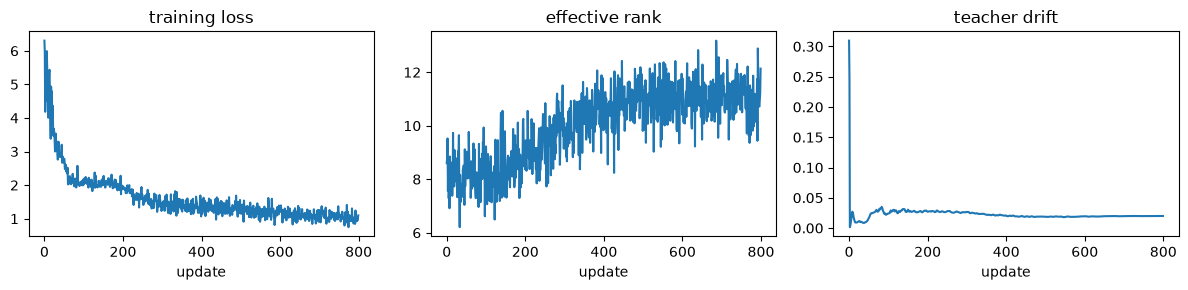

Saved a checkpoint tied to this cache, registry, fold, and configuration.


In [7]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 3, figsize=(12, 3))
for a, values, title in zip(ax, [state.losses, state.eff_rank, state.teacher_drift],
                            ['training loss', 'effective rank', 'teacher drift']):
    a.plot(values); a.set_title(title); a.set_xlabel('update')
plt.tight_layout(); plt.show()
print('Saved a checkpoint tied to this cache, registry, fold, and configuration.')

## Step 9 · Interpret the saved run, one claim at a time

**Evidence for this example:** the saved notebook output and plot from
**September 20, 2026**, plus the matching checkpoint: `laptop`, fold 0,
registry prefix `9496e61b050f`, configuration prefix `1d09c8e1eea5`.
The notebook reports `mps`; the checkpoint records **800 completed updates**,
a 32-window batch configuration, and the expected training membership.

Only the final effective rank below was printed numerically. The other
curve values are **approximate readings from the saved graph**, not exact
values recovered from a training log. These observations describe this
run; they are not promised outcomes for every rerun.

| Observation | What it supports | What it does not establish |
|---|---|---|
| Loss starts near **6**, falls quickly toward **2**, and finishes around **1** | The student and predictor become better at matching their evolving teacher targets | A 1% error rate, accurate reconstructed joint coordinates, or accurate condition labels |
| Rank is initially around **8**, later mostly **10–12**; the printed final value is **12.134796142578125** | The sampled window embeddings retain variation in several directions; this argues against complete constant-output collapse on those batches | That all variation is useful, motion-specific, or independent of camera and visibility cues |
| Drift has an initial spike near **0.31**, then stays at a few hundredths and finishes near **0.02** | After the zero-tensor caveat, this is consistent with student and teacher parameter directions remaining close | That the teacher is 2% different, that it barely moved from its starting weights, or that accuracy is high |
| Training printed **51 clips / 24 sources** and the checkpoint records **800 updates** | The expected teaching run completed and saved with the intended split context | Generalization to new source videos or new people |

**Read the curves together.** Loss decreases while rank generally increases,
rather than falling toward a single direction. That is more encouraging
than decreasing loss on its own. Drift settles after the early transient,
consistent with the intended slow-teacher setup. We can reasonably say
the run completed and its visible diagnostics do not show obvious complete
collapse. The plots do not establish that it learned the right distinctions
for the next task.

**A careful result statement:** “In fold 0, label-free S-JEPA training ran
for 800 updates on 51 clips from 24 training sources. Training loss decreased
substantially, and the final batch effective rank was 12.13. These are
encouraging optimization and representation-diversity checks. Classification
performance on unseen sources remains to be evaluated.”

If your new run differs, use this decision guide:

| Pattern | Next interpretation or check |
|---|---|
| Loss falls, but rank and embedding spread shrink toward zero | Investigate collapse before claiming useful learning |
| Loss fluctuates, but the longer trend improves and diversity remains | Random batches and masks may explain the noise; compare averages over several updates |
| Loss barely changes over a substantial budget | Check masks, gradients, learning rate, and whether updates actually ran |
| `NaN` or infinity appears | Treat the run as numerically invalid and investigate the input and training calculations |
| Rank is large, but later classification is weak | Features can encode variation that does not help distinguish the labels |

The next optional cell gives **exact numerical summaries from `state` in the
current kernel**. It compares averages over the first and last 50 updates
(or the available length in a short run) and also reports the last point.
In smoke mode those averaging ranges can overlap. It does not train or
evaluate held-out data. If the kernel has restarted, the saved plots remain
readable, but the old checkpoint format does not retain these diagnostic
histories. Do not rerun training just to claim that a new history is the old one.

In [ ]:
# Optional: run after training, while this run's `state` is still in memory.
if 'state' not in globals():
    print('No training history in this kernel. Read the saved plots above; '
          'the checkpoint does not store the old diagnostic histories.')
else:
    import numpy as np
    import pandas as pd
    from IPython.display import display

    n = len(state.losses)
    k = min(50, n)
    rows = []
    for name, values in [
        ('Loss', state.losses),
        ('Effective rank', state.eff_rank),
        ('Embedding standard deviation', state.emb_std),
        ('Teacher drift', state.teacher_drift),
    ]:
        a = np.asarray(values, dtype=float)
        rows.append({
            'Diagnostic': name,
            f'Mean of first {k} updates': a[:k].mean(),
            f'Mean of last {k} updates': a[-k:].mean(),
            'Final point': a[-1],
        })
    print(f'Current in-memory history: {n} updates. Values are not test scores.')
    display(pd.DataFrame(rows).set_index('Diagnostic').round(6))
    counts = np.asarray(list(state.source_exposure.values()))
    print(f'Observed source exposure: {counts.sum()} window draws across '
          f'{len(counts)} sources; min {counts.min()}, max {counts.max()}.')
    print('Equal sampling probabilities do not force identical observed counts.')

## Step 10 · Understand the saved model and the next experiment

The checkpoint contains the student and teacher weights, predictor,
mask placeholder, configuration, optimizer state, running center, random
generator states, schedule position, and split information. That information
allows the loading code to reject a checkpoint belonging to a different
dataset, fold, stage, or configuration. For this example its location is:

```text
artifacts/runs/full-v1/9496e61b050f/laptop-1d09c8e1eea5/fold-0/ssl.pt
```

Saving weights and training state is different from saving diagnostic
histories. This checkpoint format does not include the per-update loss,
rank, spread, or drift lists; the notebook's saved output preserves the
displayed plot and printed final rank.

What we have now is a **feature learner**. Given a window, the teacher
encoder can produce a 96-number description. There is no trained
normal/MS/PD classifier in notebook 03, so a confusion matrix, accuracy,
and macro-F1 are not outputs of this notebook.

**Notebook 04 asks whether those features help with the labels.** It compares
this checkpoint with a stage of 400 additional label-free updates. The
extra stage keeps the learned model weights but starts a fresh optimizer,
center, and schedule. For each candidate, it freezes the encoder and fits
a simple classifier, called a *linear probe*, using training clips and
their labels. Validation sources select the better candidate. A tie keeps
the shorter original run.

For that later readout, a clip's vector averages its window vectors, using
a fixed, seeded subset of teacher tokens for each window. This differs
from the all-token, per-batch embeddings used for the rank plot here.

**Notebook 05** explores training embeddings and possible shortcuts.
**Notebook 06** repeats the complete training and selection procedure with
fresh models across all five folds, then compares held-out predictions with
Random Forest, simple pose/visibility controls, and a majority baseline.
That is where we measure label prediction on unseen source videos.
Such results concern this collection's labels and source splits; they do
not by themselves establish a medical diagnostic tool.

### Check your understanding

1. **Why can't we randomly split overlapping windows?** Related motion from
   the same source could appear on both sides, making the test too easy.
2. **Where do the 264 tokens come from?** Eight time blocks times 33 landmarks.
3. **What is being predicted?** Teacher features at hidden joint–time slots.
4. **Why is the teacher allowed to see a whole window?** It supplies targets
   from training data; the student's context is restricted.
5. **Does loss 1 mean 99% accuracy?** No. It measures feature-distribution
   disagreement, not the fraction of correct condition labels.
6. **Does rank 12.13 mean training solved the task?** No. It shows several
   directions of batch variation; usefulness requires later evaluation.
7. **What result would justify moving beyond training diagnostics?** Scores
   from the planned validation/test procedure, with suitable baselines and
   the source grouping kept intact.

### Where these explanations come from

These notes describe this repository's implementation, including its
teaching choices; they are not a claim to reproduce every detail of a
published S-JEPA experiment.

| Topic | Implementation |
|---|---|
| Profiles and shapes | [configuration](sjepa/config.py), [windows](sjepa/data.py), [tokenizer](sjepa/tokenizer.py) |
| Student, predictor, teacher | [model](sjepa/models.py) |
| Masks and transformed views | [mask sampler](sjepa/masking_v2.py), [augmentation](sjepa/augment.py) |
| Loss and optimizer loop | [loss](sjepa/losses.py), [current training loop](sjepa/train_v2.py) |
| Split checks and later evaluation | [registry](sjepa/splits.py), [experiment helpers](sjepa/full_experiment.py) |